# Tarea 1 --- IELE756

**Team members:** Felipe Velásquez, Matías Moraga

**Comunas:** El Bosque, Lo Espejo, Isla de Maipo y Pirque

**Fecha:** 26/03/2026

# **Part 0: Data Loading & Joins**

0.1 Load the three Census tables

In [8]:
import pandas as pd

#Leemos solo la primera fila para ver los nombres reales de las columnas
vivienda_cols = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tarea 1/viviendas_censo2024.csv',
                             sep=';',
                             nrows=0).columns.tolist()

print("Columnas disponibles en el archivo de Vivienda:")
for col in vivienda_cols:
    print(f"- {col}")

Columnas disponibles en el archivo de Vivienda:
- id_vivienda
- region
- provincia
- comuna
- comuna_bajo_umbral
- area
- tipo_operativo
- cant_hog
- cant_per
- p2_tipo_vivienda
- p3a_estado_ocupacion
- p3b_estado_ocupacion
- p4a_mat_paredes
- p4b_mat_techo
- p4c_mat_piso
- p5_num_dormitorios
- p6_fuente_agua
- p7_distrib_agua
- p8_serv_hig
- p9_fuente_elect
- p10_basura
- p11a_num_personas
- p11b_comparte_gasto
- p11c_num_hogar
- indice_hacinamiento


In [11]:
#Leemos los nombres de las columnas del archivo Hogar
hogar_cols = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tarea 1/hogares_censo2024.csv',
                           sep=';',
                           nrows=0).columns.tolist()

print("Columnas disponibles en el archivo de Hogar:")
for col in hogar_cols:
    print(f"- {col}")

Columnas disponibles en el archivo de Hogar:
- id_vivienda
- id_hogar
- region
- provincia
- comuna
- comuna_bajo_umbral
- area
- tipo_operativo
- p12_tenencia_viv
- p13_comb_cocina
- p14_comb_calefaccion
- p15a_serv_tel_movil
- p15b_serv_compu
- p15c_serv_tablet
- p15d_serv_internet_fija
- p15e_serv_internet_movil
- p15f_serv_internet_satelital
- tipologia_hogar


In [13]:
#Leemos los nombres de las columnas del archivo Hogar
persona_cols = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tarea 1/personas_censo2024.csv',
                             sep=';',
                             nrows=0).columns.tolist()

print("Columnas disponibles en el archivo de Persona:")
for col in persona_cols:
    print(f"- {col}")

Columnas disponibles en el archivo de Persona:
- id_vivienda
- id_hogar
- id_persona
- region
- provincia
- comuna
- comuna_bajo_umbral
- area
- tipo_operativo
- sexo
- edad
- edad_quinquenal
- parentesco
- p23_est_civil
- p24_lug_resid5
- p24_lug_resid5_esp
- p25_lug_nacimiento
- p25_lug_nacimiento_rec
- p25_lug_nacimiento_esp
- p26_llegada_periodo
- p27_nacionalidad
- p27_nacionalidad_esp
- p27_nacionalidad_rec
- p28_autoid_pueblo
- p28_pueblo_pert
- p29_afrodescendencia_rec
- p29_afrodescendencia
- p30_lengua_indigena
- p30_lengua_indigena_rec
- p31_religion
- p31_religion_rec
- p32a_dificultad_ver
- p32b_dificultad_oir
- p32c_dificultad_mover
- p32d_dificultad_cogni
- p32e_dificultad_cuidado
- p32f_dificultad_comunic
- discapacidad
- p33_edu_asiste
- asistencia_parv
- asistencia_basica
- asistencia_media
- asistencia_superior
- p37_alfabet
- escolaridad
- cine11
- sit_fuerza_trabajo
- p40_cise_rec
- depend_econ_deficit_hab
- cod_ciuo
- cod_caenes
- p44_lug_trab
- p44_lug_trab_esp
-

Carga de datos y filtro de columnas para cada archivo

In [92]:
#1. Definimos las columnas
cols_vivienda_existentes = [
    'id_vivienda',
    'region',
    'comuna',
    'p4a_mat_paredes',
    'p4b_mat_techo',
    'p4c_mat_piso'
]

#2. Cargamos el archivo con el separador correcto (;)
vivienda = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tarea 1/viviendas_censo2024.csv',
                       sep=';',
                       usecols=cols_vivienda_existentes)

#3. Renombramos 'comuna' a 'codigo_comuna' para que coincida con las instrucciones
vivienda = vivienda.rename(columns={'comuna': 'codigo_comuna'})

#4. Mostramos el head
vivienda.head()

,id_vivienda,region,codigo_comuna,p4a_mat_paredes,p4b_mat_techo,p4c_mat_piso
0,1,5,5802,5.0,1.0,2.0
1,2,4,4303,2.0,3.0,3.0
2,3,11,11202,2.0,3.0,1.0
3,4,1,1101,1.0,2.0,1.0
4,5,8,8301,2.0,3.0,1.0


In [12]:
#1. Definimos las columnas
cols_hogar_reales = ['id_vivienda', 'id_hogar', 'p12_tenencia_viv']

#2. Cargamos el archivo Hogar
hogar = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tarea 1/hogares_censo2024.csv',
                    sep=';',
                    usecols=cols_hogar_reales)

#3. Renombramos para que coincida con el PDF
hogar = hogar.rename(columns={'p12_tenencia_viv': 'tenencia'})

hogar.head()

,id_vivienda,id_hogar,tenencia
0,1,1,4.0
1,2,1,9.0
2,3,1,3.0
3,4,1,3.0
4,5,1,1.0


In [14]:
#1. Definimos las columnas
cols_persona_solicitadas = [
    'id_vivienda', 'id_hogar', 'id_persona', 'sexo', 'edad',
    'p27_nacionalidad', 'p27_nacionalidad_rec', 'p24_lug_resid5',
    'p25_lug_nacimiento', 'p26_llegada_periodo', 'escolaridad',
    'cine11', 'sit_fuerza_trabajo',
    'cod_ciuo', 'cod_caenes', 'p45_medio_transporte'
]

#2. Cargamos el archivo Persona
persona = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tarea 1/personas_censo2024.csv',
                      sep=';',
                      usecols=cols_persona_solicitadas)

#3. Mostramos el head
persona.head()

Cargando personas_censo2024.csv... Por favor espera un momento.
Carga de Persona completada.


,id_vivienda,id_hogar,id_persona,sexo,edad,p24_lug_resid5,p25_lug_nacimiento,p26_llegada_periodo,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,cine11,sit_fuerza_trabajo,cod_ciuo,cod_caenes,p45_medio_transporte
0,1,1,1,2,80,3,2,NaN,1,1,17,9,3.0,NaN,NaN,NaN
1,1,1,2,1,52,2,2,NaN,1,1,14,6,1.0,7.0,F,2.0
2,1,1,3,2,45,2,2,NaN,1,1,12,6,1.0,2.0,P,3.0
3,1,1,4,2,8,2,1,NaN,1,1,2,3,NaN,NaN,NaN,NaN
4,2,1,1,1,69,3,2,NaN,1,1,12,6,3.0,NaN,NaN,NaN


0.2 Filter to your comunas

In [93]:
#1. Definimos códigos de comuna
MY_COMUNAS = [13105, 13116, 13603, 13202]

#2. Filtrar la tabla vivienda
viv = vivienda[vivienda["codigo_comuna"].isin(MY_COMUNAS)].copy()

#3. Filtrar hogar y persona basándose en las viviendas filtradas
hog = hogar[hogar["id_vivienda"].isin(viv["id_vivienda"])].copy()
per = persona[persona["id_vivienda"].isin(viv["id_vivienda"])].copy()

#Reporte de número de filas
print("--- Reporte 0.2: Filas filtradas ---")
print(f"Número de filas en vivienda: {len(viv)}")
print(f"Número de filas en hogar: {len(hog)}")
print(f"Número de filas en persona: {len(per)}")

--- Reporte 0.2: Filas filtradas ---
Número de filas en vivienda: 102826
Número de filas en hogar: 100244
Número de filas en persona: 310886


0.3 Join the tables

In [94]:
#1. Unimos persona con hogar (usando las dos llaves: id_vivienda e id_hogar)
#2. Luego unimos el resultado con vivienda (usando id_vivienda)
df = per.merge(hog, on=["id_vivienda", "id_hogar"], how="left") \
        .merge(viv, on="id_vivienda", how="left")

#3. Verificación de seguridad
#El número de filas final debe ser igual al número de personas original.
assert len(df) == len(per), "¡Error! La cantidad de filas no coincide después del join."

#4. Reportar shape e info
print(f"Reporte 0.3: El DataFrame final tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
print("\n--- Información detallada del DataFrame (df.info()) ---")
df.info()

Reporte 0.3: El DataFrame final tiene 310886 filas y 22 columnas.

--- Información detallada del DataFrame (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310886 entries, 0 to 310885
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id_vivienda           310886 non-null  int64  
 1   id_hogar              310886 non-null  int64  
 2   id_persona            310886 non-null  int64  
 3   sexo                  310886 non-null  int64  
 4   edad                  310886 non-null  int64  
 5   p24_lug_resid5        310886 non-null  int64  
 6   p25_lug_nacimiento    310886 non-null  int64  
 7   p26_llegada_periodo   20304 non-null   float64
 8   p27_nacionalidad      310886 non-null  int64  
 9   p27_nacionalidad_rec  310886 non-null  int64  
 10  escolaridad           310886 non-null  int64  
 11  cine11                310886 non-null  int64  
 12  sit_fuerza_trabajo    255016 non-

In [95]:
#1. Creamos un diccionario para las comunas
nombres_comunas = {
    13105: "El Bosque",
    13116: "Lo Espejo",
    13603: "Isla de Maipo",
    13202: "Pirque"
}

#2. Creamos la columna 'nombre_comuna' en el df usando .map()
df['nombre_comuna'] = df['codigo_comuna'].map(nombres_comunas)

#3. Verificamos que se haya creado correctamente
print("Verificación de nombres de comuna:")
print(df[['codigo_comuna', 'nombre_comuna']].drop_duplicates())

Verificación de nombres de comuna:
     codigo_comuna  nombre_comuna
0            13603  Isla de Maipo
4            13105      El Bosque
12           13116      Lo Espejo
109          13202         Pirque


Visualización rápida de la unión

In [96]:
display(df[['nombre_comuna','codigo_comuna', 'edad', 'sexo', 'tenencia', 'p4a_mat_paredes']].head(10))

,nombre_comuna,codigo_comuna,edad,sexo,tenencia,p4a_mat_paredes
0,Isla de Maipo,13603,75,1,1.0,2.0
1,Isla de Maipo,13603,66,2,1.0,2.0
2,Isla de Maipo,13603,41,2,1.0,2.0
3,Isla de Maipo,13603,7,1,1.0,2.0
4,El Bosque,13105,48,1,1.0,2.0
5,El Bosque,13105,49,2,1.0,2.0
6,El Bosque,13105,15,1,1.0,2.0
7,El Bosque,13105,56,1,1.0,2.0
8,El Bosque,13105,50,1,1.0,2.0
9,El Bosque,13105,55,2,1.0,2.0


# **Part 1: Demographic Profile**

Cantidad de habitantes por comuna

In [97]:
#1. Calcular el total general de habitantes en las 4 comunas
total_habitantes = len(df)

#2. Calcular la cantidad de habitantes por cada comuna
poblacion_por_comuna = df['nombre_comuna'].value_counts().reset_index()
poblacion_por_comuna.columns = ['Comuna', 'Habitantes']

#3. Mostrar los resultados
print(f"POBLACIÓN TOTAL (4 COMUNAS): {total_habitantes:,} personas")
print("-" * 40)
print("Desglose por comuna:")
display(poblacion_por_comuna)

POBLACIÓN TOTAL (4 COMUNAS): 310,886 personas
----------------------------------------
Desglose por comuna:


,Comuna,Habitantes
0,El Bosque,155257
1,Lo Espejo,87295
2,Isla de Maipo,39274
3,Pirque,29060


1.1 Age pyramid by sex

/tmp/ipykernel_5210/2932773435.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(abs(x))) for x in xticks])


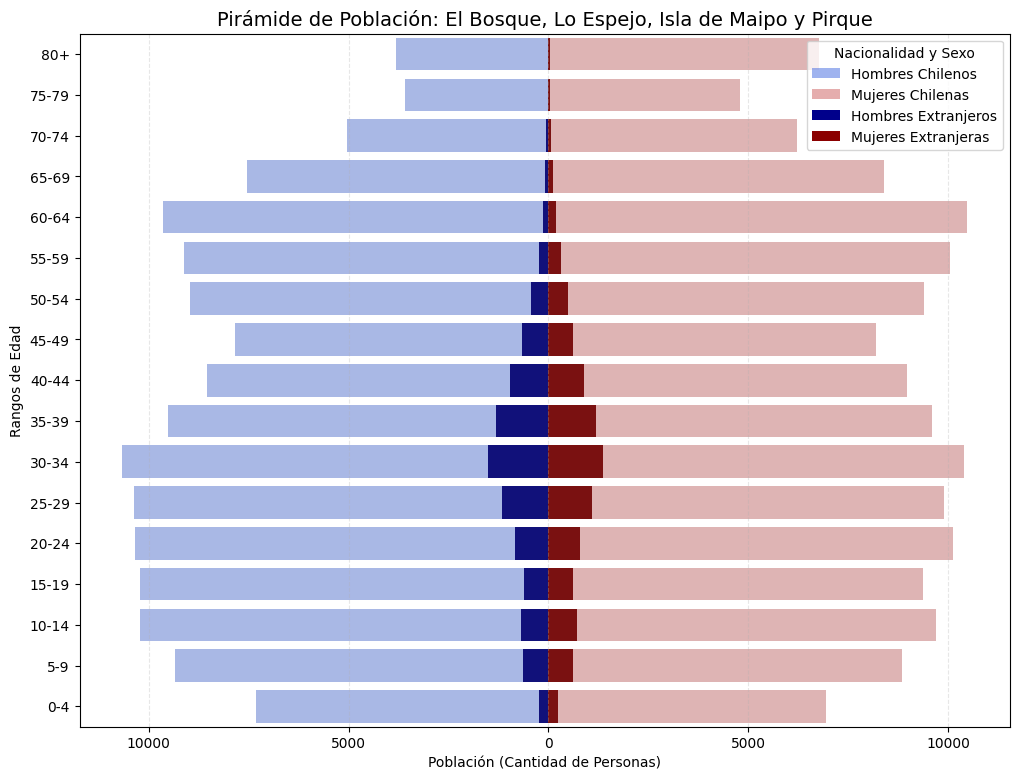

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

#1. Limpieza y preparación
df_clean = df[df["edad"] != -99].copy()
bins = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]
df_clean["age_group"] = pd.cut(df_clean["edad"], bins=bins, labels=labels, right=False)

#2. Agrupar datos
pyramid_data = df_clean.groupby(['age_group', 'sexo', 'p27_nacionalidad_rec'], observed=False).size().reset_index(name='count')
pyramid_data.loc[pyramid_data['sexo'] == 1, 'count'] *= -1 #Hombres a la izquierda

#3. Definir colores
#Chilenos: Azul y Rojo estándar / Extranjeros: Versiones más oscuras
c_h_chi, c_m_chi = 'royalblue', 'indianred'
c_h_ext, c_m_ext = 'darkblue', 'darkred'

#4. Graficar
fig, ax = plt.subplots(figsize=(12, 9))

#Capa 1: Chilenos (p27_nacionalidad_rec == 1)
sns.barplot(data=pyramid_data[pyramid_data['p27_nacionalidad_rec'] == 1],
            x='count', y='age_group', hue='sexo',
            palette={1: c_h_chi, 2: c_m_chi}, dodge=False, alpha=0.5, ax=ax)

#Capa 2: Extranjeros (p27_nacionalidad_rec == 2) - Overlay
sns.barplot(data=pyramid_data[pyramid_data['p27_nacionalidad_rec'] == 2],
            x='count', y='age_group', hue='sexo',
            palette={1: c_h_ext, 2: c_m_ext}, dodge=False, alpha=1.0, ax=ax)

#A. Invertir el eje Y para que 0-4 esté abajo
ax.invert_yaxis()

#B. Etiquetas del eje X
xticks = ax.get_xticks()
ax.set_xticklabels([str(int(abs(x))) for x in xticks])

#C. Crear Leyenda con colores
legend_elements = [
    Patch(facecolor=c_h_chi, alpha=0.5, label='Hombres Chilenos'),
    Patch(facecolor=c_m_chi, alpha=0.5, label='Mujeres Chilenas'),
    Patch(facecolor=c_h_ext, label='Hombres Extranjeros'),
    Patch(facecolor=c_m_ext, label='Mujeres Extranjeras')
]
ax.legend(handles=legend_elements, loc='upper right', title='Nacionalidad y Sexo')

#Detalles finales
plt.title('Pirámide de Población: El Bosque, Lo Espejo, Isla de Maipo y Pirque', fontsize=14)
plt.xlabel('Población (Cantidad de Personas)')
plt.ylabel('Rangos de Edad')
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

1.2 Dependency ratio

In [99]:
#1. Filtramos las edades válidas (excluyendo -99)
df_dep = df[df['edad'] != -99].copy()

#2. Clasificamos a las personas en los tres grupos
#0-14 años: Niños (dependientes)
#15-64 años: Población en edad de trabajar (activos)
#65+ años: Adultos mayores (dependientes)
def clasificar_dependencia(edad):
    if edad < 15:
        return '0-14'
    elif edad < 65:
        return '15-64'
    else:
        return '65+'

df_dep['grupo_dep'] = df_dep['edad'].apply(clasificar_dependencia)

#3. Agrupamos por comuna y contamos cuántos hay en cada grupo
tabla_dep = df_dep.groupby(['nombre_comuna', 'grupo_dep']).size().unstack(fill_value=0)

#4. Aplicamos la fórmula del PDF: (Pob 0-14 + Pob 65+) / Pob 15-64
tabla_dep['dependency_ratio'] = (tabla_dep['0-14'] + tabla_dep['65+']) / tabla_dep['15-64']

#5. Mostramos el resultado final
print("--- 1.2 Dependency Ratio por Comuna ---")
display(tabla_dep[['0-14', '15-64', '65+', 'dependency_ratio']])

--- 1.2 Dependency Ratio por Comuna ---


grupo_dep,0-14,15-64,65+,dependency_ratio
nombre_comuna,,,,
El Bosque,27509,103712,24036,0.497001
Isla de Maipo,7507,26615,5152,0.475634
Lo Espejo,15405,58289,13601,0.497624
Pirque,5449,19617,3994,0.481368


Is the ratio higher or lower than you expected?

Es más alto de lo que esperabamos, ya que el 50% aprox de las personas de nuestras comunas son dependientes de su grupo familiar, además podemos ver que es casi parejo en las 4 comunas el ratio.

1.3 Household size distribution

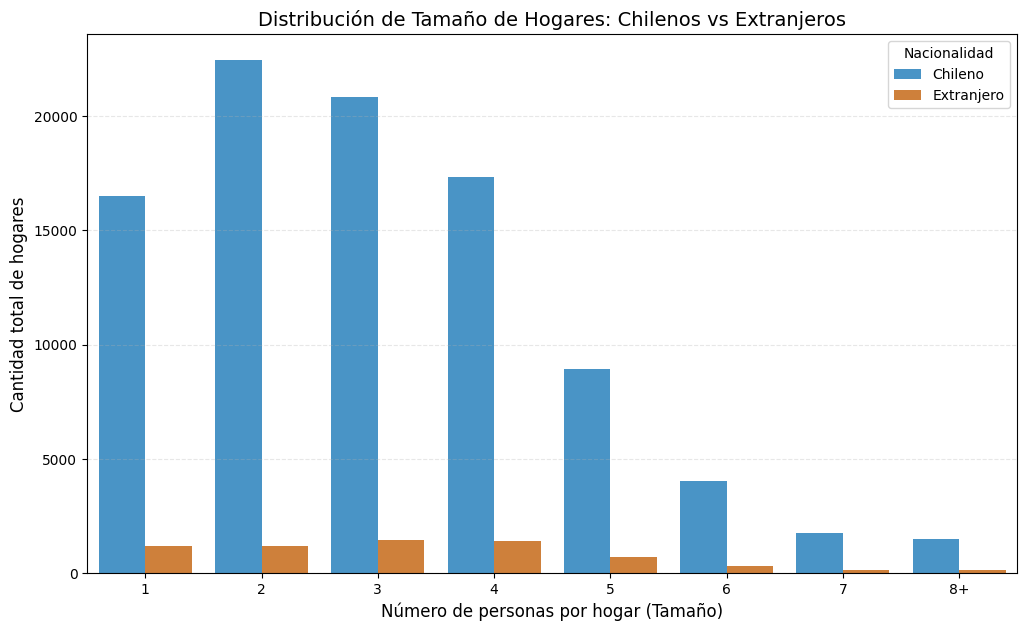

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#1. Crear un DataFrame a nivel de HOGAR (unificando personas por id_hogar)
#Tomamos la nacionalidad del primer integrante (representativo del hogar)
df_hogares = df.groupby(['id_vivienda', 'id_hogar']).agg({
    'p27_nacionalidad_rec': 'first',
    'id_persona': 'count' # Esto nos da el tamaño del hogar
}).reset_index()

#2. Renombrar columnas para claridad
df_hogares.columns = ['id_vivienda', 'id_hogar', 'nacionalidad_rec', 'tamano_hogar']

#3. Aplicar la lógica de "8+" para el eje X
df_hogares['size_label'] = df_hogares['tamano_hogar'].apply(lambda x: str(x) if x < 8 else '8+')

#4. Mapear nombres de nacionalidad
df_hogares['Nacionalidad'] = df_hogares['nacionalidad_rec'].map({1: 'Chileno', 2: 'Extranjero'})

#5. Ordenar el eje X para que sea 1, 2, 3... 8+
orden_x = [str(i) for i in range(1, 8)] + ['8+']

#6. Graficar (Barras agrupadas por nacionalidad)
plt.figure(figsize=(12, 7))

sns.countplot(data=df_hogares, x='size_label', hue='Nacionalidad',
              order=orden_x, palette={'Chileno': '#3498db', 'Extranjero': '#e67e22'})

plt.title('Distribución de Tamaño de Hogares: Chilenos vs Extranjeros', fontsize=14)
plt.xlabel('Número de personas por hogar (Tamaño)', fontsize=12)
plt.ylabel('Cantidad total de hogares', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

Se observa que los hogares con nacionalidad chilena predominan significativamente en volumen, presentando una concentración máxima en hogares de 2 y 3 integrantes, lo que sugiere una estructura predominante de familias pequeñas o parejas. En contraste, los hogares extranjeros muestran una distribución más uniforme en los tramos de 1 a 4 personas, con su punto más alto en hogares de 3 integrantes. En ambos grupos, la frecuencia de hogares muy numerosos (de 6 a 8+ personas) es marcadamente baja, confirmando que en estas comunas la tendencia general apunta hacia hogares de tamaño reducido o mediano.

1.4 Education and employment

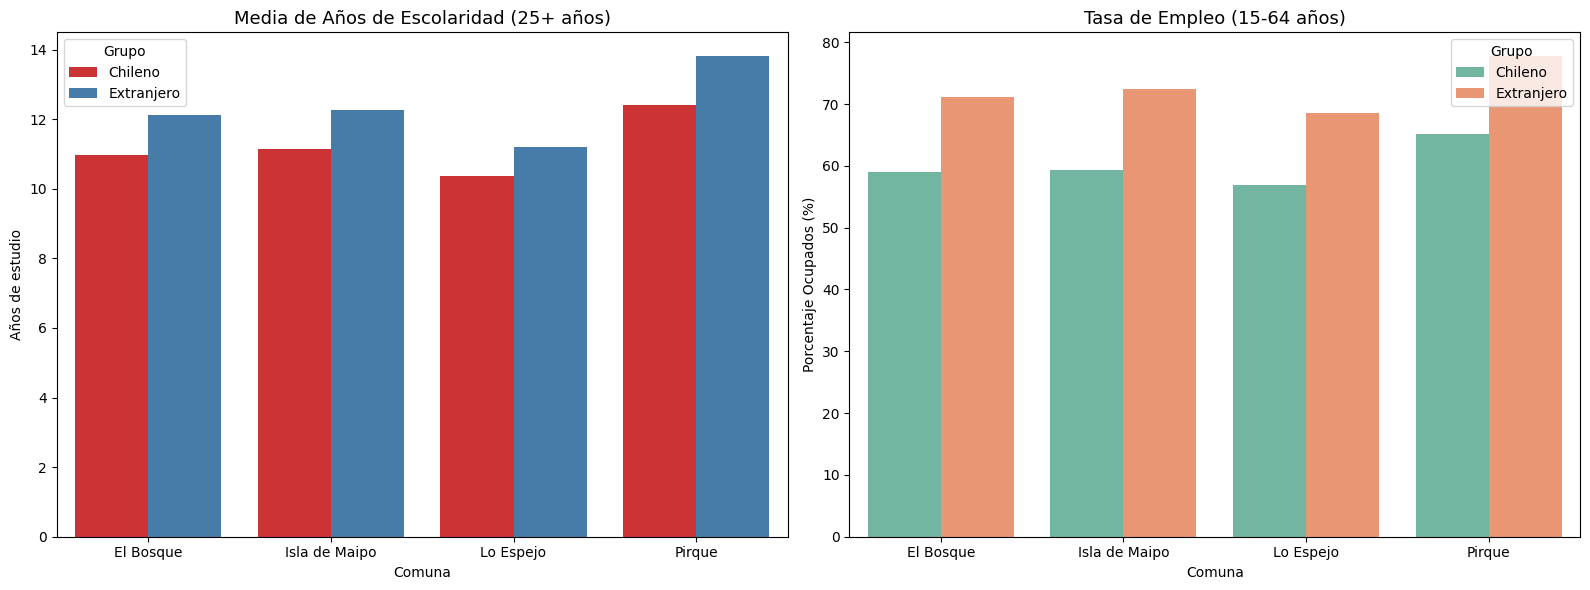

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#1. Limpieza y preparación (Excluir valores -99)
#Filtramos de una vez para las edades y variables que necesitamos
df_edu = df[(df['edad'] >= 25) & (df['escolaridad'] != -99)].copy()
df_emp = df[(df['edad'] >= 15) & (df['edad'] <= 64) & (df['sit_fuerza_trabajo'] != -99)].copy()

#Mapeo de nacionalidad para las leyendas
nacionalidad_map = {1: 'Chileno', 2: 'Extranjero'}
df_edu['Grupo'] = df_edu['p27_nacionalidad_rec'].map(nacionalidad_map)
df_emp['Grupo'] = df_emp['p27_nacionalidad_rec'].map(nacionalidad_map)

#2. Calcular promedios por comuna y grupo
#Escolaridad (Promedio de años)
escolaridad_res = df_edu.groupby(['nombre_comuna', 'Grupo'])['escolaridad'].mean().reset_index()

#Empleo (Proporción de ocupados, donde sit_fuerza_trabajo == 1)
df_emp['ocupado'] = (df_emp['sit_fuerza_trabajo'] == 1).astype(int)
empleo_res = df_emp.groupby(['nombre_comuna', 'Grupo'])['ocupado'].mean().reset_index()
empleo_res['ocupado'] = empleo_res['ocupado'] * 100 # Convertir a porcentaje

#3. Crear los gráficos (Subplots para ver ambos al mismo tiempo)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#Gráfico 1: Escolaridad
sns.barplot(data=escolaridad_res, x='nombre_comuna', y='escolaridad', hue='Grupo',
            palette='Set1', ax=ax1)
ax1.set_title('Media de Años de Escolaridad (25+ años)', fontsize=13)
ax1.set_ylabel('Años de estudio')
ax1.set_xlabel('Comuna')

#Gráfico 2: Empleo
sns.barplot(data=empleo_res, x='nombre_comuna', y='ocupado', hue='Grupo',
            palette='Set2', ax=ax2)
ax2.set_title('Tasa de Empleo (15-64 años)', fontsize=13)
ax2.set_ylabel('Porcentaje Ocupados (%)')
ax2.set_xlabel('Comuna')

plt.tight_layout()
plt.show()

En cuanto a la escolaridad, se observa que en las cuatro comunas la población extranjera posee, en promedio, más años de estudio que la chilena, destacando Pirque como la comuna con los niveles educativos más altos para ambos grupos. Esta diferencia sugiere un perfil migratorio con mayor formación académica o técnica, lo que eleva el promedio educativo general de los residentes extranjeros en comparación con los locales en estas zonas.

Respecto a la tasa de empleo, existe una brecha marcada a favor de la población extranjera, quienes presentan niveles de ocupación significativamente más altos que los chilenos en todas las comunas analizadas. Este fenómeno es especialmente visible en Pirque y El Bosque, lo que refleja una población migrante compuesta mayoritariamente por adultos en edad productiva con una alta inserción y participación activa en el mercado laboral local.

# **Part 2: Migration Landscape**

2.1 Percentage foreign-born by comuna

--- 2.1 Porcentaje de Población Extranjera por Comuna ---


,Comuna,Porcentaje Extranjeros
0,El Bosque,6.860882
1,Isla de Maipo,3.391557
2,Lo Espejo,7.459763
3,Pirque,1.520991


/tmp/ipykernel_5210/3214827379.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tabla_migracion, x='Comuna', y='Porcentaje Extranjeros', palette='viridis')


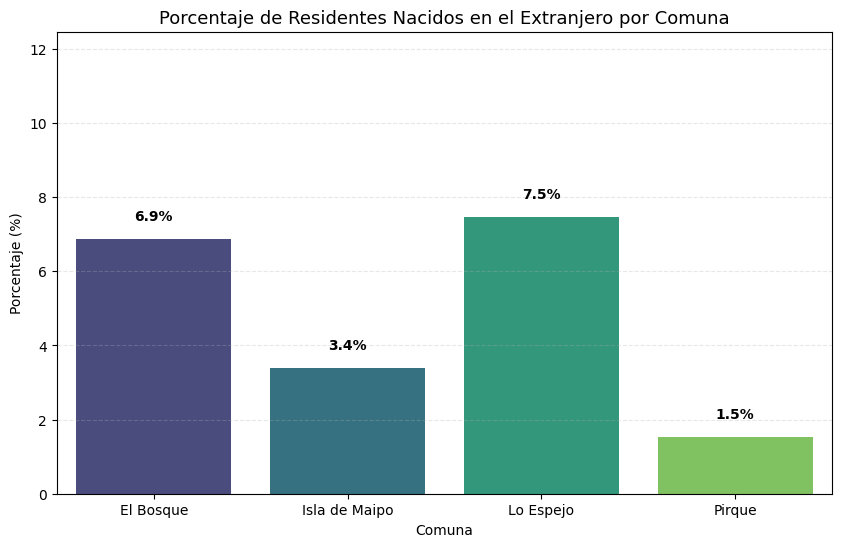

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#1. Calcular población total por comuna
total_por_comuna = df.groupby('nombre_comuna').size()

#2. Calcular población extranjera por comuna (donde p27_nacionalidad_rec == 2)
extranjeros_por_comuna = df[df['p27_nacionalidad_rec'] == 2].groupby('nombre_comuna').size()

#3. Calcular el porcentaje
#Usamos fillna(0) por si alguna comuna no tuviera extranjeros
tabla_migracion = (extranjeros_por_comuna / total_por_comuna * 100).fillna(0).reset_index()
tabla_migracion.columns = ['Comuna', 'Porcentaje Extranjeros']

#4. Mostrar la tabla simple
print("--- 2.1 Porcentaje de Población Extranjera por Comuna ---")
display(tabla_migracion)

#5. Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=tabla_migracion, x='Comuna', y='Porcentaje Extranjeros', palette='viridis')

plt.title('Porcentaje de Residentes Nacidos en el Extranjero por Comuna', fontsize=13)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Comuna')
plt.ylim(0, max(tabla_migracion['Porcentaje Extranjeros']) + 5) #Espacio arriba para etiquetas

#Añadir el número del porcentaje sobre cada barra para que sea más claro
for i, val in enumerate(tabla_migracion['Porcentaje Extranjeros']):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

2.2 Top nationalities

Vemos en que columna se encuentra el codigo de pais

In [103]:
#Vamos a leer solo 5 filas de las columnas de especificación para ver qué contienen
inspeccion = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tarea 1/personas_censo2024.csv',
                         sep=';',
                         usecols=['p27_nacionalidad_rec', 'p27_nacionalidad_esp', 'p25_lug_nacimiento_esp'],
                         nrows=100) # Leemos 100 para asegurar que agarramos algún extranjero

#Filtramos para ver solo donde hay extranjeros
print("Muestra de datos de nacionalidad detallada:")
display(inspeccion[inspeccion['p27_nacionalidad_rec'] == 2].head(10))

Muestra de datos de nacionalidad detallada:


,p25_lug_nacimiento_esp,p27_nacionalidad_esp,p27_nacionalidad_rec
18,862,862,2
19,862,862,2
20,862,862,2
21,862,862,2
22,862,862,2
23,862,862,2
85,862,862,2
86,862,862,2
87,862,862,2


Cargarmos la columna de nacionalidad

In [105]:
#1. Cargamos solo los IDs y la columna detallada para no saturar la memoria
print("Cargando códigos de países...")
extra_cols = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tarea 1/personas_censo2024.csv',
                         sep=';',
                         usecols=['id_vivienda', 'id_hogar', 'id_persona', 'p27_nacionalidad_esp'])

#2. La pegamos a nuestro dataframe principal 'df'
df = df.merge(extra_cols, on=['id_vivienda', 'id_hogar', 'id_persona'], how='left')

print("¡Listo! Columna agregada.")

Cargando códigos de países...
¡Listo! Columna agregada.


Vemos el Top 10 de códigos (Paises)

In [106]:
#1. Filtramos por extranjeros
ext_df = df[df['p27_nacionalidad_rec'] == 2]

#2. Contamos el top 10 de la nueva columna
top_10_conteo = ext_df['p27_nacionalidad_esp'].value_counts().head(10).reset_index()
top_10_conteo.columns = ['Código', 'Cantidad']

print("Top 10 códigos encontrados:")
display(top_10_conteo)

Top 10 códigos encontrados:


,Código,Cantidad
0,862,7631
1,332,4225
2,604,2490
3,170,1956
4,68,844
5,5,793
6,32,331
7,13,330
8,142,142
9,150,112


Creamos el gráfico con los nombres reales

/tmp/ipykernel_5210/3229450769.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_grafico, x='Cantidad', y='País', palette='magma')


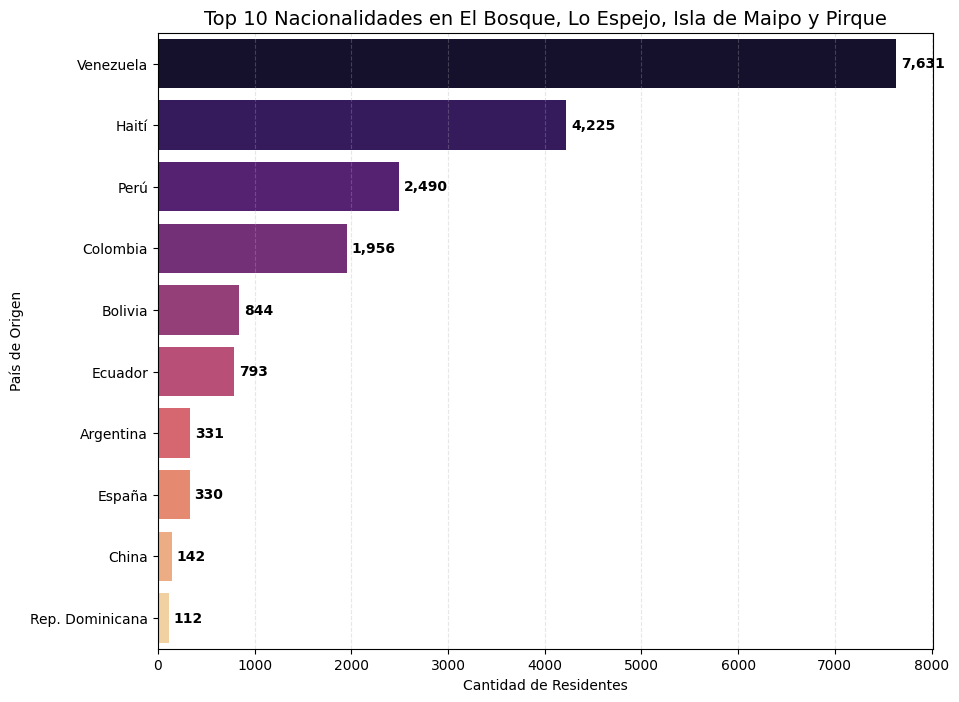

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

#1. Definimos el mapeo exacto para tus 10 códigos encontrados
mapeo_paises = {
    862: "Venezuela",
    332: "Haití",
    604: "Perú",
    170: "Colombia",
    5:   "Ecuador",
    68:  "Bolivia",
    13:  "España",
    32:  "Argentina",
    142: "China",
    150: "Rep. Dominicana"
}

#2. Tomamos los resultados
top_10_grafico = top_10_conteo.copy()

#3. Aplicamos los nombres de los países
top_10_grafico['País'] = top_10_grafico['Código'].map(mapeo_paises)

#4. Crear el gráfico de barras horizontales
plt.figure(figsize=(10, 8))
sns.barplot(data=top_10_grafico, x='Cantidad', y='País', palette='magma')

plt.title('Top 10 Nacionalidades en El Bosque, Lo Espejo, Isla de Maipo y Pirque', fontsize=14)
plt.xlabel('Cantidad de Residentes')
plt.ylabel('País de Origen')

#Añadir los números al final de cada barra
for i, v in enumerate(top_10_grafico['Cantidad']):
    plt.text(v + 50, i, f'{int(v):,}', va='center', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

2.3 Migration status: residence 5 years ago

Agregamos la columna con el lugar de residencia

In [109]:
#Traemos la columna de especificación de comuna
extra_mig = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tarea 1/personas_censo2024.csv',
                        sep=';',
                        usecols=['id_vivienda', 'id_hogar', 'id_persona', 'p24_lug_resid5_esp'])

#La unimos a nuestro df
if 'p24_lug_resid5_esp' not in df.columns:
    df = df.merge(extra_mig, on=['id_vivienda', 'id_hogar', 'id_persona'], how='left')

Graficamos

/tmp/ipykernel_5210/3105098930.py:48: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Patch(facecolor=colores_vivos[i], label=f"{categorias[i]}: {promedios[i]:.1f}% promedio")


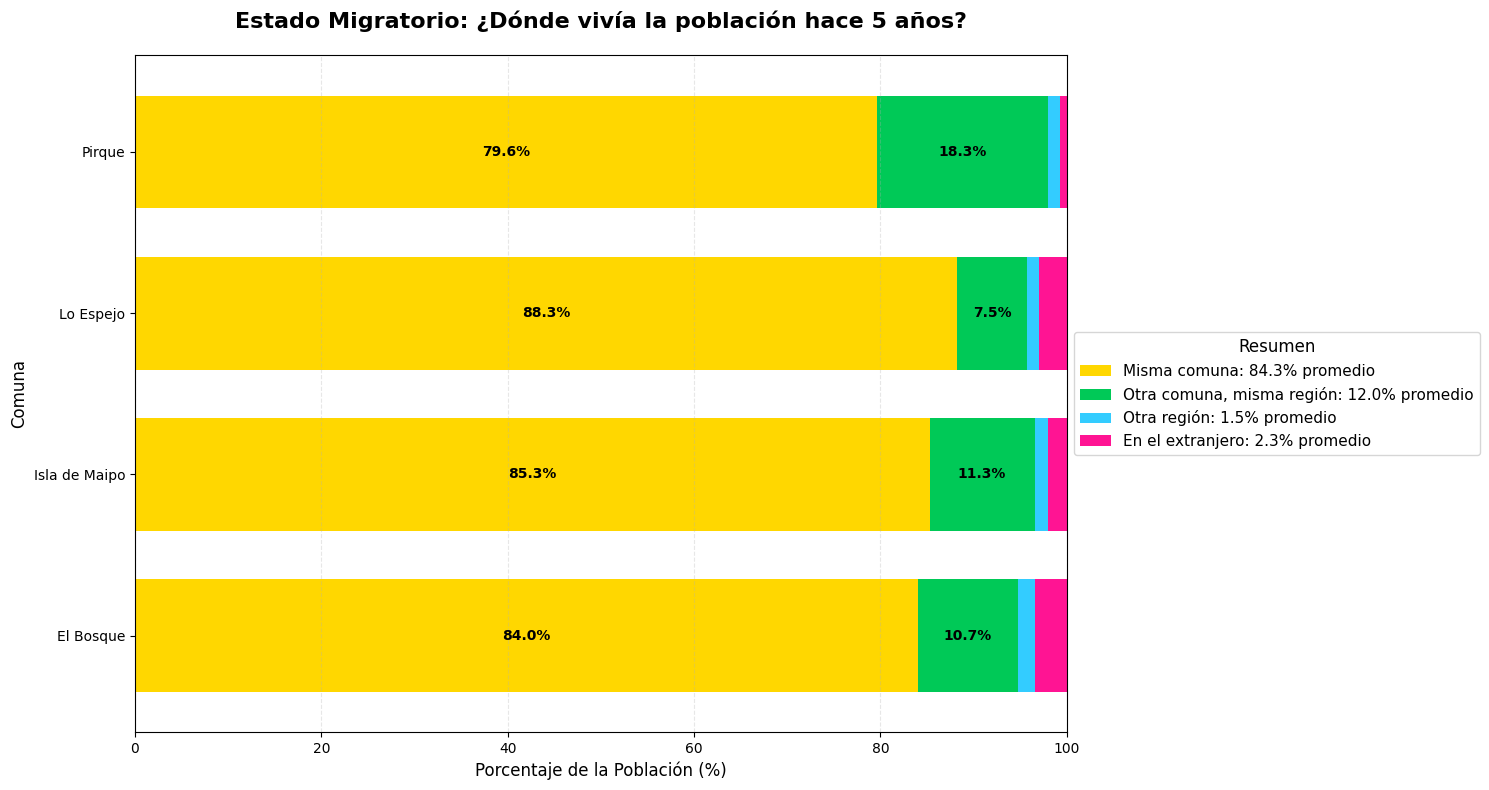

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

#1. Preparación de datos
df_mig = df[(df['edad'] >= 5) & (df['p24_lug_resid5'] != -99)].copy()

def calcular_status(row):
    cod = row['p24_lug_resid5']
    comuna_ant = row['p24_lug_resid5_esp']
    if cod == 2: return "Misma comuna"
    if cod == 4: return "En el extranjero"
    if cod == 3:
        #13 es Metropolitana. El código de comuna // 1000 nos da la región
        if (comuna_ant // 1000) == 13: return "Otra comuna, misma región"
        else: return "Otra región"
    return "Otro"

df_mig['status_final'] = df_mig.apply(calcular_status, axis=1)

#2. Tabla de porcentajes ordenada
categorias = ["Misma comuna", "Otra comuna, misma región", "Otra región", "En el extranjero"]
tabla = df_mig.groupby(['nombre_comuna', 'status_final'], observed=False).size().unstack(fill_value=0)
tabla = tabla.reindex(columns=categorias, fill_value=0)
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

#3. Colores
colores_vivos = ['#FFD700', '#00C957', '#33CCFF', '#FF1493'] # Dorado, Verde, Celeste, Rosa

#4. Graficar
fig, ax = plt.subplots(figsize=(15, 8))
#Desactivamos la leyenda automática de plot() poniendo legend=False
tabla_pct.plot(kind='barh', stacked=True, color=colores_vivos, ax=ax, width=0.7, legend=False)

#5. Agregar etiquetas de datos dentro de las barras (solo si son mayores al 4%)
for n, x in enumerate(tabla_pct.index):
    cum = 0
    for i, cat in enumerate(categorias):
        val = tabla_pct.loc[x, cat]
        if val > 4:
            ax.text(cum + val/2, n, f'{val:.1f}%', va='center', ha='center',
                    color='black', fontweight='bold', fontsize=10) # Texto en negro para resaltar sobre colores alegres
        cum += val

#6. Resumen de Porcentajes (Color + Promedio)
promedios = tabla_pct.mean()
legend_elements = [
    Patch(facecolor=colores_vivos[i], label=f"{categorias[i]}: {promedios[i]:.1f}% promedio")
    for i in range(len(categorias))
]
#Ubicamos la leyenda a la derecha
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5),
          title="Resumen", fontsize=11, title_fontsize=12)

#Estética final
plt.title('Estado Migratorio: ¿Dónde vivía la población hace 5 años?', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Porcentaje de la Población (%)', fontsize=12)
plt.ylabel('Comuna', fontsize=12)
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

2.4 Arrival period of immigrants

/tmp/ipykernel_5210/985986306.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=distribucion, x='Periodo', y='Cantidad', palette=colores_alegres)


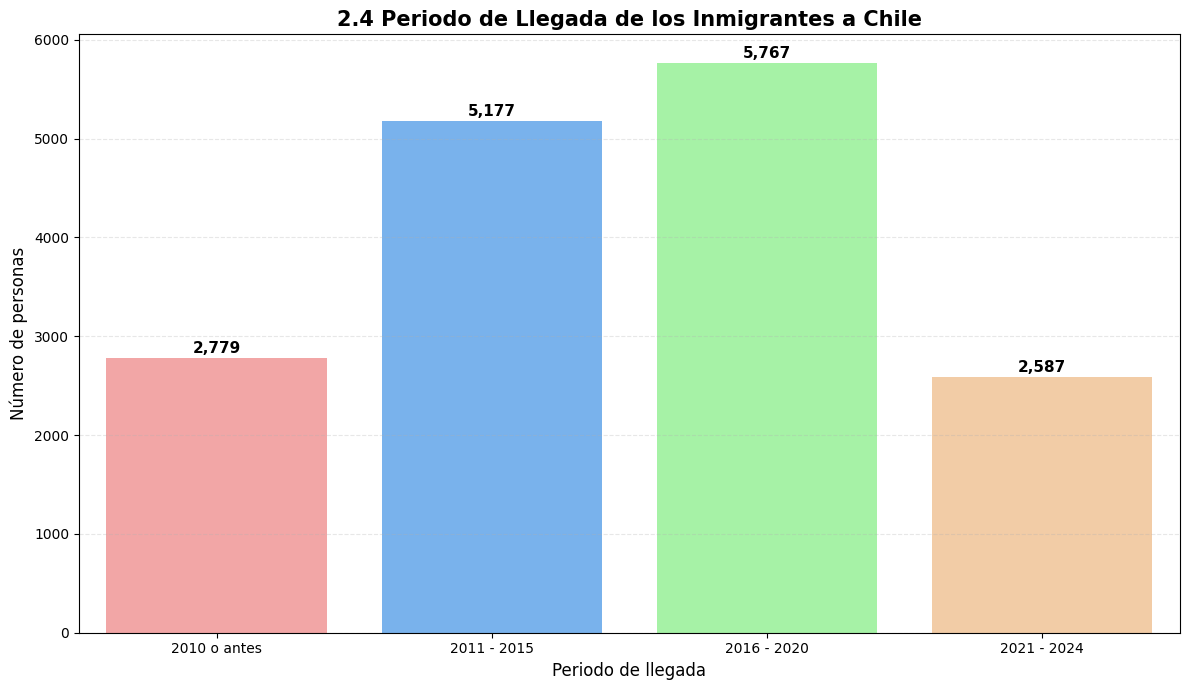


Distribución porcentual del periodo de llegada:
periodo_llegada
2016 - 2020     35.4
2011 - 2015     31.7
2010 o antes    17.0
2021 - 2024     15.9
Name: proportion, dtype: float64


In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos: Solo extranjeros y que tengan el dato del periodo (distinto de -99)
df_llegada = df[(df['p27_nacionalidad_rec'] == 2) & (df['p26_llegada_periodo'] != -99)].copy()

# 2. Mapeo de los periodos de llegada
periodo_map = {
    1: "2010 o antes",
    2: "2011 - 2015",
    3: "2016 - 2020",
    4: "2021 - 2024"
}
df_llegada['periodo_llegada'] = df_llegada['p26_llegada_periodo'].map(periodo_map)

# 3. Calcular la distribución total (todas las comunas combinadas)
distribucion = df_llegada['periodo_llegada'].value_counts().reindex(periodo_map.values()).reset_index()
distribucion.columns = ['Periodo', 'Cantidad']

# 4. Graficar
plt.figure(figsize=(12, 7))
colores_alegres = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'] # Colores pastel/vivos

sns.barplot(data=distribucion, x='Periodo', y='Cantidad', palette=colores_alegres)

plt.title('2.4 Periodo de Llegada de los Inmigrantes a Chile', fontsize=15, fontweight='bold')
plt.xlabel('Periodo de llegada', fontsize=12)
plt.ylabel('Número de personas', fontsize=12)

# Añadir etiquetas de cantidad sobre las barras
for i, v in enumerate(distribucion['Cantidad']):
    plt.text(i, v + 50, f'{int(v):,}', ha='center', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Imprimir porcentajes para el análisis
print("\nDistribución porcentual del periodo de llegada:")
print((df_llegada['periodo_llegada'].value_counts(normalize=True) * 100).round(1))

Al analizar el periodo de llegada, se observa que la inmigración en estas comunas es un fenómeno predominantemente reciente. Más del 80% de la población extranjera actual arribó al país después del año 2011, con un notable incremento en el quinquenio 2016-2020. Aunque existe un grupo de '2.609 personas que llegaron en 2010 o antes, este es minoritario frente al volumen de migración recibida en la última década, lo que ha transformado rápidamente el perfil demográfico de El Bosque, Lo Espejo, Isla de Maipo y Pirque.

# **Part 3: Spatial Visualization**

3.1 Choropleth map: population by comuna

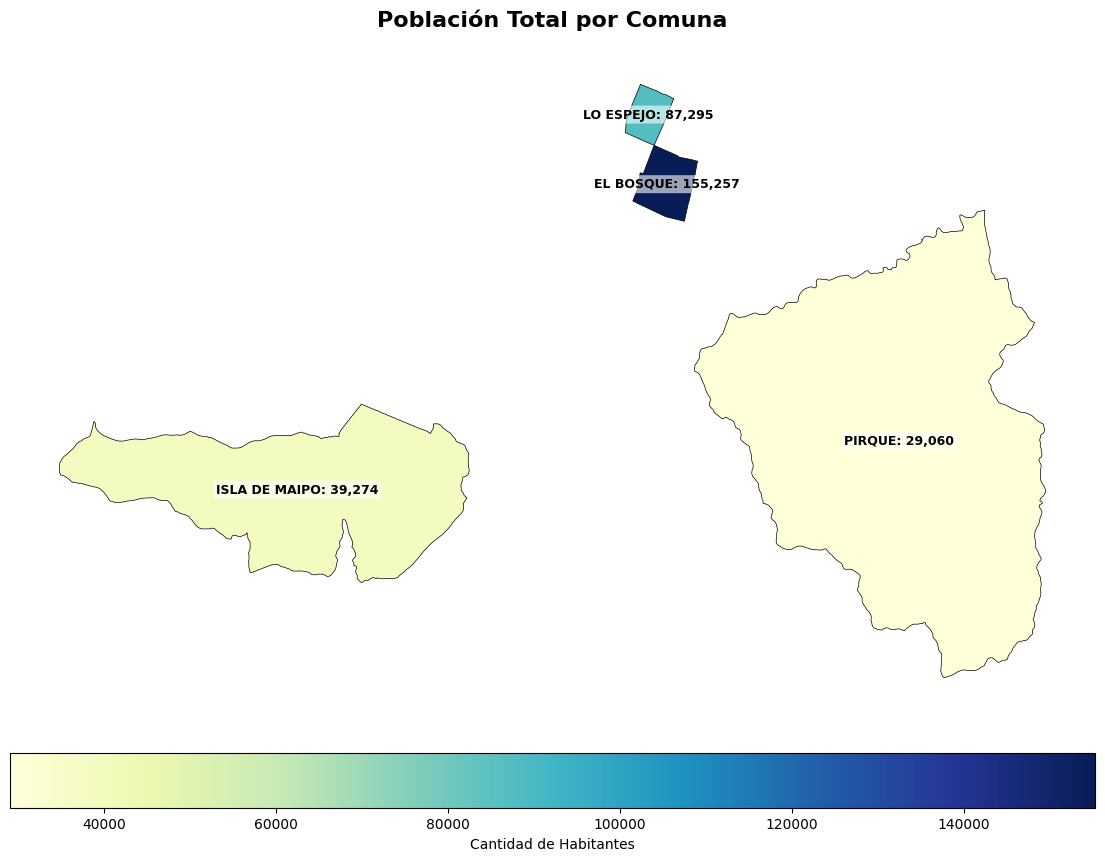

In [120]:
import matplotlib.pyplot as plt

#1. Preparar datos de población total
pop_data = df.groupby('codigo_comuna').size().reset_index(name='poblacion_total')

#2. Filtrar el mapa y unir los datos
mapa_31 = comunas_gdf[comunas_gdf['CUT'].astype(int).isin(MY_COMUNAS)].copy()
mapa_31['CUT'] = mapa_31['CUT'].astype(int)
mapa_final_31 = mapa_31.merge(pop_data, left_on='CUT', right_on='codigo_comuna')

# 3. Graficar
fig, ax = plt.subplots(figsize=(14, 12))
mapa_final_31.plot(column='poblacion_total', cmap='YlGnBu', legend=True,
                   edgecolor='black', linewidth=0.5, ax=ax,
                   legend_kwds={'label': "Cantidad de Habitantes", 'orientation': "horizontal", 'pad': 0.05})

#Etiquetas
for idx, row in mapa_final_31.iterrows():
    # Formato: "COMUNA: 140.000"
    texto = f"{row['COMUNA']}: {int(row['poblacion_total']):,}"

    ax.annotate(text=texto,
                xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                ha='center', va='center',
                fontsize=9, fontweight='bold', color='black',
                #Esto agrega un fondo blanco sutil para que el texto resalte
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))

plt.title('Población Total por Comuna', fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.show()

3.2 Choropleth map: % foreign-born by comuna

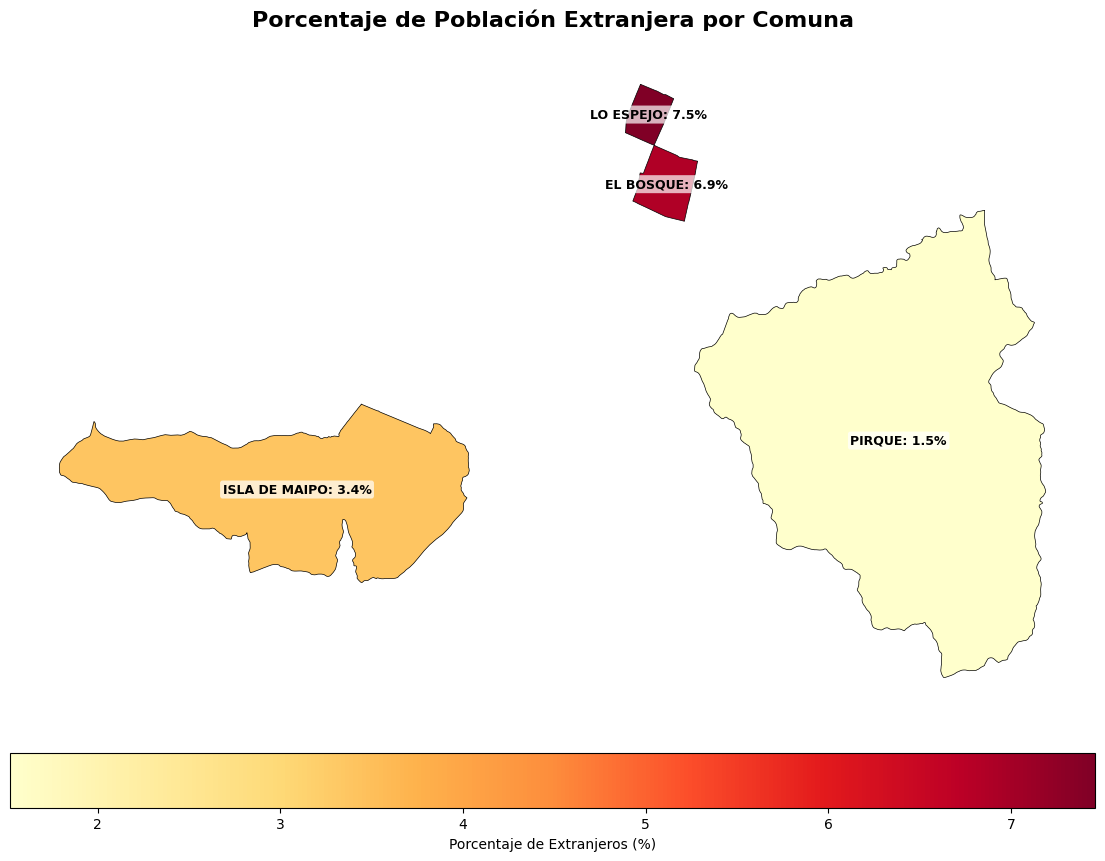

In [122]:
import matplotlib.pyplot as plt

#1. Calcular el porcentaje de extranjeros por comuna (p27_nacionalidad_rec == 2)
totales = df.groupby('codigo_comuna').size()
extranjeros = df[df['p27_nacionalidad_rec'] == 2].groupby('codigo_comuna').size()
pct_data = (extranjeros / totales * 100).fillna(0).reset_index(name='pct_extranjeros')

#2. Filtrar el mapa y unir los datos (reutilizando el mapa filtrado anteriormente)
mapa_32 = mapa_31.drop(columns='poblacion_total', errors='ignore').merge(pct_data, left_on='CUT', right_on='codigo_comuna')

#3. Graficar
fig, ax = plt.subplots(figsize=(14, 12))
mapa_32.plot(column='pct_extranjeros', cmap='YlOrRd', legend=True,
             edgecolor='black', linewidth=0.5, ax=ax,
             legend_kwds={'label': "Porcentaje de Extranjeros (%)", 'orientation': "horizontal", 'pad': 0.05})

#Etiquetas
for idx, row in mapa_32.iterrows():
    # Formato: "COMUNA: X.X%"
    texto = f"{row['COMUNA']}: {row['pct_extranjeros']:.1f}%"

    ax.annotate(text=texto,
                xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                ha='center', va='center',
                fontsize=9, fontweight='bold', color='black',
                # Recuadro blanco semi-transparente para resaltar el texto
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

plt.title('Porcentaje de Población Extranjera por Comuna', fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.show()

# **Part 4: Comuna-Level Summary Table**

In [123]:
import pandas as pd
import numpy as np
import os

#1. Definir la función build_summary que procesará cada comuna
def build_summary(group):
    # Filtros de nacionalidad (1: Chileno, 2: Extranjero)
    chilean = group[group['p27_nacionalidad_rec'] == 1]
    foreign = group[group['p27_nacionalidad_rec'] == 2]

    # --- Cálculos de Población ---
    pop_total = len(group)
    pop_chilean = len(chilean)
    pop_foreign = len(foreign)
    pct_foreign = (pop_foreign / pop_total) * 100 if pop_total > 0 else 0

    # --- Edad Mediana (excluyendo -99) ---
    median_age_chilean = chilean[chilean['edad'] != -99]['edad'].median()
    median_age_foreign = foreign[foreign['edad'] != -99]['edad'].median()

    # --- Escolaridad Media (Edad 25+ y excluyendo -99) ---
    mean_schooling_chilean = chilean[(chilean['edad'] >= 25) & (chilean['escolaridad'] != -99)]['escolaridad'].mean()
    mean_schooling_foreign = foreign[(foreign['edad'] >= 25) & (foreign['escolaridad'] != -99)]['escolaridad'].mean()

    # --- Tasa de Empleo (Edad 15-64, sit_fuerza_trabajo == 1) ---
    # Chilenos
    activos_chi = chilean[(chilean['edad'] >= 15) & (chilean['edad'] <= 64)]
    emp_rate_chilean = (activos_chi['sit_fuerza_trabajo'] == 1).mean() * 100 if len(activos_chi) > 0 else 0
    # Extranjeros
    activos_for = foreign[(foreign['edad'] >= 15) & (foreign['edad'] <= 64)]
    emp_rate_foreign = (activos_for['sit_fuerza_trabajo'] == 1).mean() * 100 if len(activos_for) > 0 else 0

    # --- Razón de Dependencia (Total comuna) ---
    pop_0_14 = len(group[group['edad'] < 15])
    pop_65_mas = len(group[group['edad'] >= 65])
    pop_15_64 = len(group[(group['edad'] >= 15) & (group['edad'] <= 64)])
    dependency_ratio = (pop_0_14 + pop_65_mas) / pop_15_64 if pop_15_64 > 0 else 0

    return pd.Series({
        'nombre_comuna': group['nombre_comuna'].iloc[0],
        'pop_total': pop_total,
        'pop_chilean': pop_chilean,
        'pop_foreign': pop_foreign,
        'pct_foreign': pct_foreign,
        'median_age_chilean': median_age_chilean,
        'median_age_foreign': median_age_foreign,
        'mean_schooling_chilean': mean_schooling_chilean,
        'mean_schooling_foreign': mean_schooling_foreign,
        'emp_rate_chilean': emp_rate_chilean,
        'emp_rate_foreign': emp_rate_foreign,
        'dependency_ratio': dependency_ratio
    })

#2. Aplicar la función agrupando por el código de la comuna
print("Generando tabla resumen... por favor espera.")
summary = df.groupby("codigo_comuna").apply(build_summary).reset_index()

#3. Crear carpeta de salida si no existe y guardar el CSV
if not os.path.exists('output'):
    os.makedirs('output')

summary.to_csv("output/tarea1_comuna_summary.csv", index=False)

#4. Mostrar el resultado final
print("\n--- TABLA RESUMEN FINAL (PARTE 4) ---")
display(summary)

Generando tabla resumen... por favor espera.

--- TABLA RESUMEN FINAL (PARTE 4) ---


/tmp/ipykernel_5210/373390907.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby("codigo_comuna").apply(build_summary).reset_index()


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13105,El Bosque,155257,143714,10652,6.860882,37.0,31.0,10.971926,12.114083,58.937127,71.021600,0.497001
1,13116,Lo Espejo,87295,80266,6512,7.459763,38.0,32.0,10.356598,11.212395,56.828001,68.394742,0.497624
2,13202,Pirque,29060,28398,442,1.520991,37.0,40.0,12.411691,13.803815,65.068493,77.715877,0.481368
3,13603,Isla de Maipo,39274,37775,1332,3.391557,37.0,31.0,11.147838,12.256439,59.301640,72.289157,0.475634


Descarga del archivo summary

In [125]:
from google.colab import files

# Descargar el archivo que generamos en el paso anterior
files.download("output/tarea1_comuna_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Copia en drive

In [126]:
# Guardar una copia directamente en tu carpeta de Drive
ruta_drive = "/content/drive/MyDrive/Colab Notebooks/Tarea 1/tarea1_comuna_summary.csv"
summary.to_csv(ruta_drive, index=False)
#
print(f"Archivo guardado permanentemente en: {ruta_drive}")

Archivo guardado permanentemente en: /content/drive/MyDrive/Colab Notebooks/Tarea 1/tarea1_comuna_summary.csv
